<a href="https://colab.research.google.com/github/piblors/Introducao-a-ciencia-de-dados-e-IA-iesb-/blob/main/Trabalhodecienciadedados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto Final: Análise Exploratória do Mercado de Trabalho e Predição de Salários
**Disciplina:** Introdução à ciência de dados.

**Dataset**: Kaggle Job Salary Prediction Dataset.

**Aluno**: Pablo Cauã Novais Barbosa




In [23]:
import kagglehub
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import glob


%matplotlib inline
sns.set_theme(style="whitegrid")

path = kagglehub.dataset_download("nalisha/job-salary-prediction-dataset")

arquivos_csv = glob.glob(os.path.join(path, "*.csv"))

df_jobs = pd.read_csv(arquivos_csv[0])
display(df_jobs.head())

Using Colab cache for faster access to the 'job-salary-prediction-dataset' dataset.


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


## Qual é a distribuição geral dos salários?




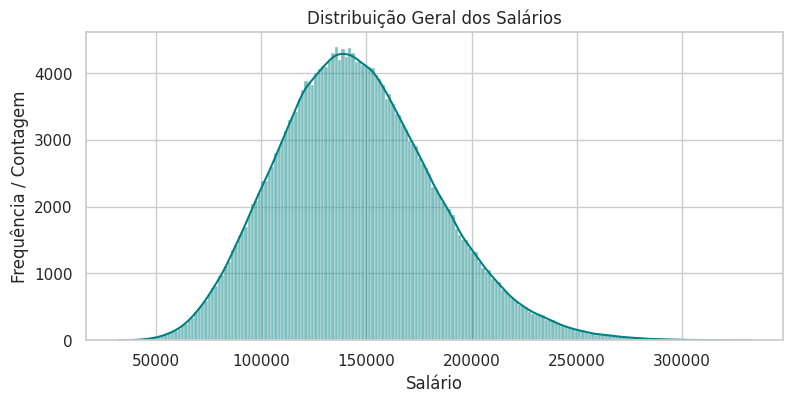

In [3]:
plt.figure(figsize=(9, 4))
sns.histplot(data=df_jobs, x='salary', kde=True, color='teal')
plt.title('Distribuição Geral dos Salários')
plt.xlabel('Salário')
plt.ylabel('Frequência / Contagem')
plt.show()

##Como o tempo de experiência influencia no valor do salário?

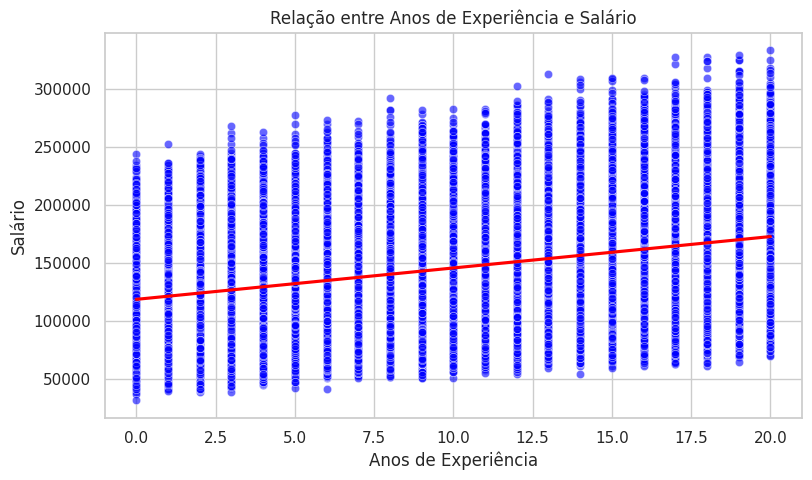

In [5]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df_jobs, x='experience_years', y='salary', alpha=0.6, color='blue')
sns.regplot(data=df_jobs, x='experience_years', y='salary', scatter=False, color='red')
plt.title('Relação entre Anos de Experiência e Salário')
plt.xlabel('Anos de Experiência')
plt.ylabel('Salário')
plt.show()

# Existe uma diferença salarial significativa com base no nível de escolaridade?

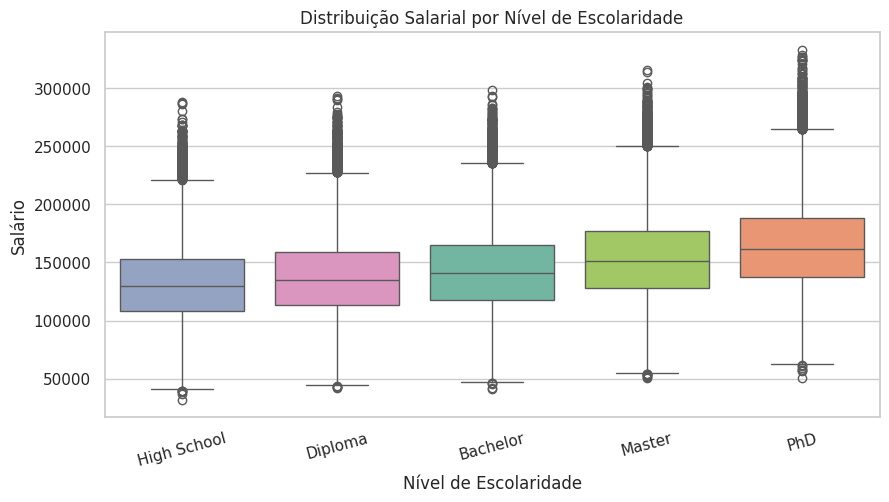

In [7]:
plt.figure(figsize=(10, 5))
ordem_educacao = df_jobs.groupby('education_level')['salary'].median().sort_values().index
sns.boxplot(data=df_jobs, x='education_level', y='salary', order=ordem_educacao, palette='Set2', hue='education_level', legend=False)
plt.title('Distribuição Salarial por Nível de Escolaridade')
plt.xlabel('Nível de Escolaridade')
plt.ylabel('Salário')
plt.xticks(rotation=15)
plt.show()

# Profissionais que atuam em trabalho remoto ganham mais do que quem trabalha presencialmente?

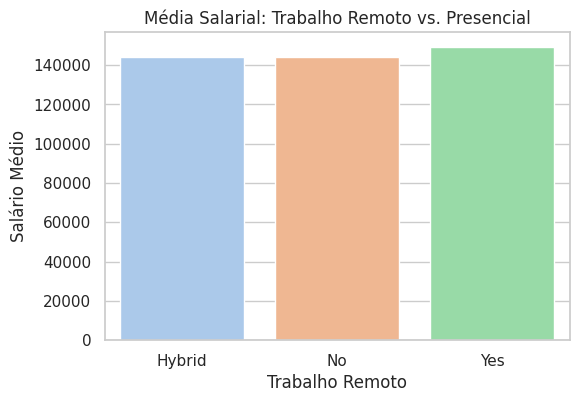

In [9]:
plt.figure(figsize=(6, 4))
sns.barplot(data=df_jobs, x='remote_work', y='salary', palette='pastel', errorbar=None, hue='remote_work', legend=False)
plt.title('Média Salarial: Trabalho Remoto vs. Presencial')
plt.xlabel('Trabalho Remoto')
plt.ylabel('Salário Médio')
plt.show()

# Quais são as 5 áreas ou cargos que apresentam as maiores médias salariais?

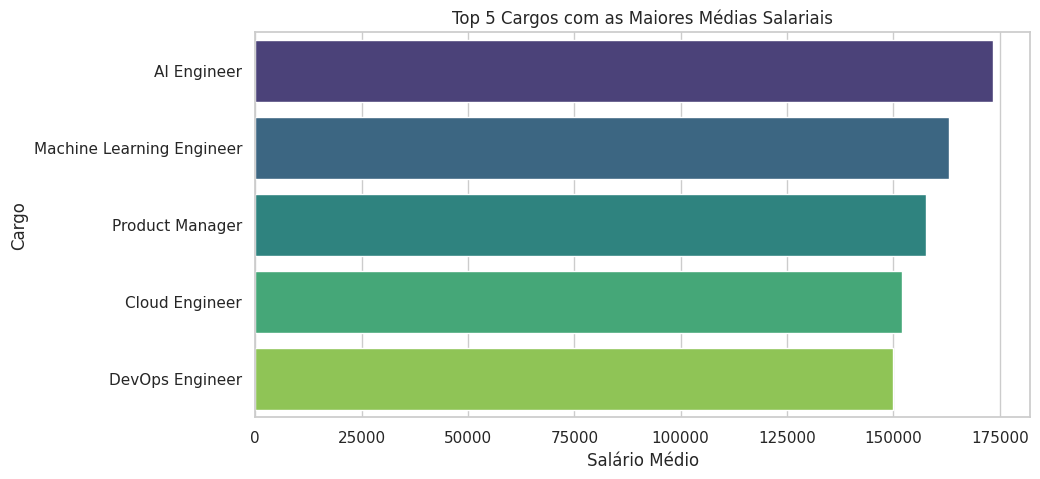

In [11]:
plt.figure(figsize=(10, 5))
top_cargos = df_jobs.groupby('job_title')['salary'].mean().sort_values(ascending=False).head(5).reset_index()
sns.barplot(data=top_cargos, y='job_title', x='salary', palette='viridis', hue='job_title', legend=False)
plt.title('Top 5 Cargos com as Maiores Médias Salariais')
plt.xlabel('Salário Médio')
plt.ylabel('Cargo')
plt.show()

# Possuir uma quantidade maior de habilidades está diretamente associado a um salário maior?

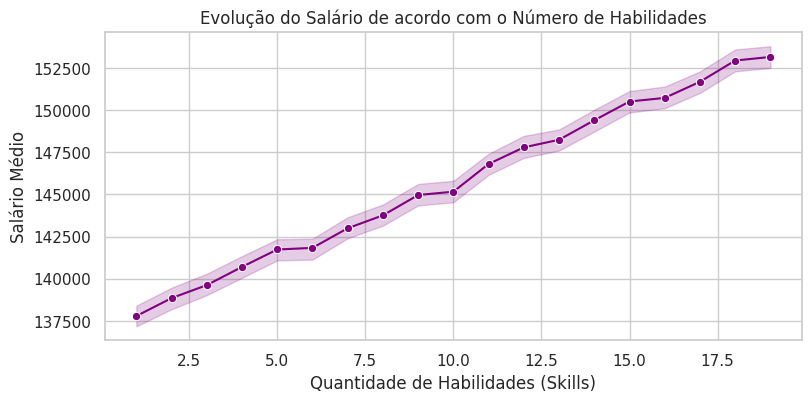

In [12]:
plt.figure(figsize=(9, 4))
sns.lineplot(data=df_jobs, x='skills_count', y='salary', marker='o', color='purple')
plt.title('Evolução do Salário de acordo com o Número de Habilidades')
plt.xlabel('Quantidade de Habilidades (Skills)')
plt.ylabel('Salário Médio')
plt.show()

# Como está dividido o volume de profissionais por localização geográfica?

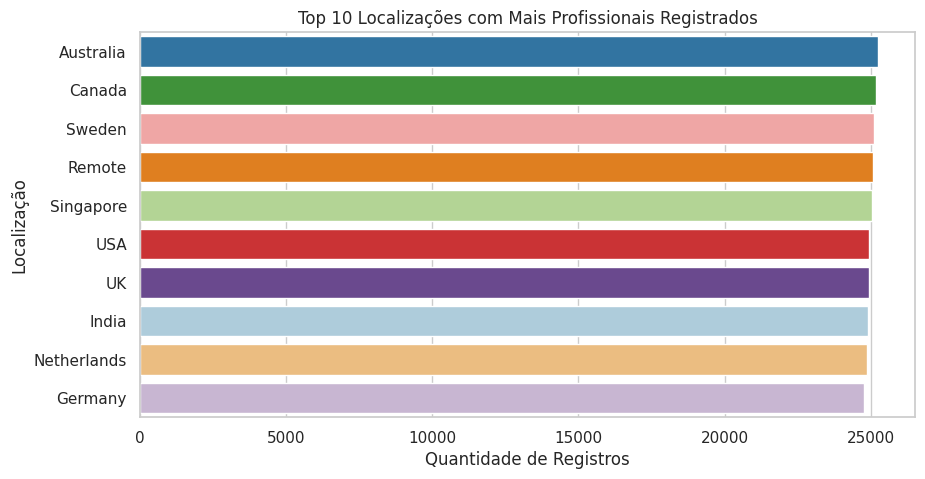

In [15]:
plt.figure(figsize=(10, 5))
top_locais = df_jobs['location'].value_counts().head(10).index
sns.countplot(data=df_jobs[df_jobs['location'].isin(top_locais)], y='location', order=top_locais, palette='Paired', hue='location', legend=False)
plt.title('Top 10 Localizações com Mais Profissionais Registrados')
plt.xlabel('Quantidade de Registros')
plt.ylabel('Localização')
plt.show()

# A presença de certificações profissionais impacta positivamente na remuneração?

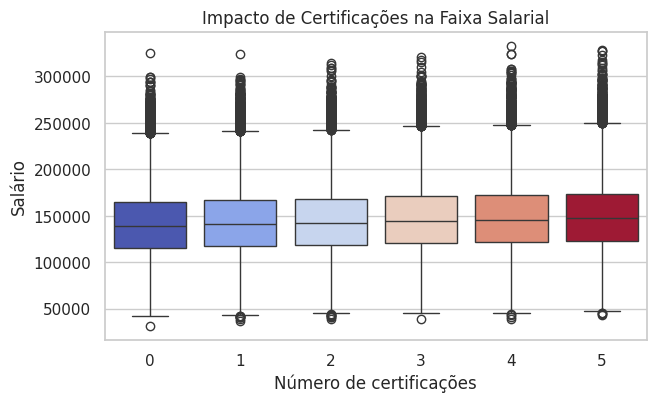

In [19]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df_jobs, x='certifications', y='salary', palette='coolwarm', hue='certifications', legend=False)
plt.title('Impacto de Certificações na Faixa Salarial')
plt.xlabel('Número de certificações')
plt.ylabel('Salário')
plt.show()